* Qwen Tutorial

* Part A. 구조
    <br>1. Settings & Structure
    <br>2. Vision 구조 (ViT: patch_embed, pos_embed, blocks)
    <br>3. Merger 구조 (MLP projector, deepstack)
    <br>4. Text 구조 (tokenizer, embed_tokens)
    <br>5. Decoder 구조 (GQA, SwiGLU, RMSNorm)
    <br>6. LM Head 구조
    
* Part B. 예시
    <br> 7. 하나의 이미지+텍스트 예시를 처음부터 끝까지 따라가기
        <br>7.1 입력 준비 (이미지+텍스트 원본)
        <br>7.2 Vision 경로: 이미지 → 리사이즈 → patch → ViT → merger 
        <br>7.3 Text 경로: 텍스트 → tokenize → embed
        <br>7.4 Sequence 결합: 두 경로가 합쳐지는 지점 (2752+17=2769)
        <br>7.5 Decoder → LM Head → 출력

* Part C. 추론/파인튜닝 실습
<br>8. Text Reasoning (chat, generate)
<br>9. Batch Inference
<br>10. Fine-tuning


---

Import

In [1]:
import os 
import torch
import matplotlib.pyplot as plt

In [2]:
# GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, GPU Count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Total mem: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f}GB")

Device: cuda, GPU Count: 1
GPU name: NVIDIA B200
Total mem: 178.35GB


## Part A. 구조


#### 1.Setting
* model
* tokenizer
* config 

In [3]:
# base + multi-modal, qwen3.5
from transformers import Qwen3_5ForConditionalGeneration, AutoProcessor
from transformers import BitsAndBytesConfig

model_name = "Qwen/Qwen3.5-27B"                              # HF Hub 모델 저장소 ID (이름표)
quant_config = BitsAndBytesConfig(load_in_4bit=True)         # 가중치 4bit 압축 로드  

processor = AutoProcessor.from_pretrained(model_name)       # 같은 모델용 전처리기

model = Qwen3_5ForConditionalGeneration.from_pretrained(
    model_name,                                             # Hub에서 가중치 로드
    quantization_config=quant_config,                       # 4bit 압축해서 GPU에 로드
    device_map="auto", 
)                                    
model = torch.compile(model)                            # 컴파일(최적화를 위해 설정)
model.generation_config = model.generation_config

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

In [4]:
# chat / instruct model, qwen3-VL
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

MODEL_PATH = "Qwen/Qwen3-VL-8B-Instruct"

# tokenize를 포함한 통합 processor
processor = AutoProcessor.from_pretrained(MODEL_PATH)

# model initialize
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()                                        
# .eval()은 명시적 설정
# visual + language model

model.generation_config = model.generation_config

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

In [5]:
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"{name:10s} | {module.__class__.__name__:15s} | {n_params/1e6:10.1f}M params")

    # 한 단계 더 아래로
    for sub_name, sub_module in module.named_children():
        sub_n_params = sum(p.numel() for p in sub_module.parameters())
        print(f"    └─ {sub_name:20s}: {sub_module.__class__.__name__:25s} | {sub_n_params/1e6:10.1f}M params")

model      | Qwen3VLModel    |     8144.8M params
    └─ visual              : Qwen3VLVisionModel        |      576.4M params
    └─ language_model      : Qwen3VLTextModel          |     7568.4M params
lm_head    | Linear          |      622.3M params


In [6]:
def print_module_tree(module, prefix="", depth=0, max_depth=3):
    if depth > max_depth:
        return
    for name, child in module.named_children():
        print(f"{prefix}{name}: {child.__class__.__name__}")
        print_module_tree(child, f"{prefix}{name}.", depth + 1, max_depth)

print_module_tree(model, max_depth=3)

model: Qwen3VLModel
model.visual: Qwen3VLVisionModel
model.visual.patch_embed: Qwen3VLVisionPatchEmbed
model.visual.patch_embed.proj: Conv3d
model.visual.pos_embed: Embedding
model.visual.rotary_pos_emb: Qwen3VLVisionRotaryEmbedding
model.visual.blocks: ModuleList
model.visual.blocks.0: Qwen3VLVisionBlock
model.visual.blocks.1: Qwen3VLVisionBlock
model.visual.blocks.2: Qwen3VLVisionBlock
model.visual.blocks.3: Qwen3VLVisionBlock
model.visual.blocks.4: Qwen3VLVisionBlock
model.visual.blocks.5: Qwen3VLVisionBlock
model.visual.blocks.6: Qwen3VLVisionBlock
model.visual.blocks.7: Qwen3VLVisionBlock
model.visual.blocks.8: Qwen3VLVisionBlock
model.visual.blocks.9: Qwen3VLVisionBlock
model.visual.blocks.10: Qwen3VLVisionBlock
model.visual.blocks.11: Qwen3VLVisionBlock
model.visual.blocks.12: Qwen3VLVisionBlock
model.visual.blocks.13: Qwen3VLVisionBlock
model.visual.blocks.14: Qwen3VLVisionBlock
model.visual.blocks.15: Qwen3VLVisionBlock
model.visual.blocks.16: Qwen3VLVisionBlock
model.visual.b

In [7]:
print(model.named_parameters)

<bound method Module.named_parameters of Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1152, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1152)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-26): 27 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1152, out_features=3456, bias=True)
            (proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (linear_fc2): Linear(in_features=4304, out_features=1152, bias=True)
 

In [8]:
print(model.config) 
# total config: txt, img config 포함
# img hidden size: 1152, txt hidden size: 4096

Qwen3VLConfig {
  "architectures": [
    "Qwen3VLForConditionalGeneration"
  ],
  "dtype": "bfloat16",
  "image_token_id": 151655,
  "model_type": "qwen3_vl",
  "text_config": {
    "attention_bias": false,
    "attention_dropout": 0.0,
    "bos_token_id": 151643,
    "dtype": "bfloat16",
    "eos_token_id": 151645,
    "head_dim": 128,
    "hidden_act": "silu",
    "hidden_size": 4096,
    "initializer_range": 0.02,
    "intermediate_size": 12288,
    "max_position_embeddings": 262144,
    "model_type": "qwen3_vl_text",
    "num_attention_heads": 32,
    "num_hidden_layers": 36,
    "num_key_value_heads": 8,
    "pad_token_id": null,
    "rms_norm_eps": 1e-06,
    "rope_parameters": {
      "mrope_interleaved": true,
      "mrope_section": [
        24,
        20,
        20
      ],
      "rope_theta": 5000000,
      "rope_type": "default"
    },
    "use_cache": true,
    "vocab_size": 151936
  },
  "tie_word_embeddings": false,
  "transformers_version": "5.14.1",
  "video_token_id

In [9]:
from collections import defaultdict

stats = defaultdict(lambda: {"total": 0, "trainable": 0})

for name, param in model.named_parameters():
    top_level = name.split(".")[0]            # 최상위 서브모듈 이름으로 그룹화
    stats[top_level]['total'] += param.numel()
    if param.requires_grad:
        stats[top_level]['trainable'] += param.numel()
total_all = sum(v['total'] for v in stats.values())

print(f"{'submodule':15s} {'total':>12s} {'trainable':>12s} {'frozen?':>10s} {'% of model':>10s}")

for name, v in sorted(stats.items(), key=lambda x: -x[1]['total']):
    frozen = "FROZEN" if v["trainable"] == 0 else ("PARTIAL" if v["trainable"] < v["total"] else "TRAINABLE")
    pct = v["total"] / total_all * 100
    print(f"{name:15s} {v['total']:12d} {v['trainable']:12d} {frozen:10s} {pct:10.2f}%")
print(f"\n총 파라미터: {total_all/1e9:.2f}B")

submodule              total    trainable    frozen? % of model
model             8144793840   8144793840 TRAINABLE       92.90%
lm_head            622329856    622329856 TRAINABLE        7.10%

총 파라미터: 8.77B


#### 2. Vision 구조

* Vision Encoder > Vision-Language Adapter(Cross-Attn Resampler) > Qwen LLM Decoder

In [10]:
# ViT Structure
vision_module, vision_name = None, None
for name, module in model.named_modules():
    if "vis" in name.lower():
        vision_module, vision_name = module, name
        break

vit_core_names = ["patch_embed", "pos_embed", "rotary_pos_emb", "blocks"]
for name, child in vision_module.named_children():
    if name in vit_core_names:
        n_params = sum(p.numel() for p in child.parameters())
        print(f"{name:20s} | {child.__class__.__name__:30s} | {n_params/1e6:8.1f}M params")

patch_embed          | Qwen3VLVisionPatchEmbed        |      1.8M params
pos_embed            | Embedding                      |      2.7M params
rotary_pos_emb       | Qwen3VLVisionRotaryEmbedding   |      0.0M params
blocks               | ModuleList                     |    411.5M params


In [11]:
# Config
vis_cfg = model.config.vision_config

for k in ["hidden_size", "depth", "num_heads", "patch_size",
          "in_channels", "spatial_merge_size", "temporal_patch_size"]:
    if hasattr(vis_cfg, k):
        print(f"{k:20s}: {getattr(vis_cfg, k)}")

hidden_size         : 1152
depth               : 27
num_heads           : 16
patch_size          : 16
in_channels         : 3
spatial_merge_size  : 2
temporal_patch_size : 2


#### 3. Merger 

* spatial_merge_size  : 2

In [12]:
print("=== merger (기본) ===")
print_module_tree(vision_module.merger, max_depth=1)

merger = vision_module.merger
print(f"\nlinear_fc1: in={merger.linear_fc1.in_features}, out={merger.linear_fc1.out_features}")
print(f"linear_fc2: in={merger.linear_fc2.in_features}, out={merger.linear_fc2.out_features}")
print(f"입력 차원(4×hidden_size={vis_cfg.hidden_size}×4={vis_cfg.hidden_size*4}) → 출력 차원({merger.linear_fc2.out_features})")

print(f"\n=== deepstack_merger_list ({len(vision_module.deepstack_merger_list)}개) ===")
for i, m in enumerate(vision_module.deepstack_merger_list):
    print(f"[{i}] fc1: {m.linear_fc1.in_features}→{m.linear_fc1.out_features}, "
          f"fc2: {m.linear_fc2.in_features}→{m.linear_fc2.out_features}")

n_merger_params = sum(p.numel() for p in vision_module.merger.parameters())
n_deepstack_params = sum(p.numel() for p in vision_module.deepstack_merger_list.parameters())
print(f"\nmerger 파라미터: {n_merger_params/1e6:.1f}M")
print(f"deepstack_merger_list 파라미터: {n_deepstack_params/1e6:.1f}M")

=== merger (기본) ===
norm: LayerNorm
linear_fc1: Linear
act_fn: GELU
linear_fc2: Linear

linear_fc1: in=4608, out=4608
linear_fc2: in=4608, out=4096
입력 차원(4×hidden_size=1152×4=4608) → 출력 차원(4096)

=== deepstack_merger_list (3개) ===
[0] fc1: 4608→4608, fc2: 4608→4096
[1] fc1: 4608→4608, fc2: 4608→4096
[2] fc1: 4608→4608, fc2: 4608→4096

merger 파라미터: 40.1M
deepstack_merger_list 파라미터: 120.4M


#### 4. Text: Tokenizer + embed_tokens

In [13]:
tokenizer = processor.tokenizer

print("=== Tokenizer ===")
print(f"vocab_size: {tokenizer.vocab_size}")
print(f"실제 len(tokenizer): {len(tokenizer)}")  # added special token 포함하면 vocab_size보다 클 수 있음
print(f"special tokens: {tokenizer.special_tokens_map}")

# 이미지 관련 special token들도 special_tokens_map에 없을 수 있어서 별도 확인
for name in ["image_token_id", "vision_start_token_id", "vision_end_token_id"]:
    tid = getattr(model.config, name, None)
    if tid is not None:
        print(f"{name}: {tid} → '{tokenizer.convert_ids_to_tokens(tid)}'")

=== Tokenizer ===
vocab_size: 151643
실제 len(tokenizer): 151669
special tokens: {'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}
image_token_id: 151655 → '<|image_pad|>'
vision_start_token_id: 151652 → '<|vision_start|>'
vision_end_token_id: 151653 → '<|vision_end|>'


In [14]:
print("\n=== Token Embedding ===")
embed_tokens = model.model.language_model.embed_tokens
print(embed_tokens)
print(f"num_embeddings(vocab_size): {embed_tokens.num_embeddings}")
print(f"embedding_dim(hidden_size): {embed_tokens.embedding_dim}")
n_embed_params = sum(p.numel() for p in embed_tokens.parameters())
print(f"파라미터 수: {n_embed_params/1e6:.1f}M")



=== Token Embedding ===
Embedding(151936, 4096)
num_embeddings(vocab_size): 151936
embedding_dim(hidden_size): 4096
파라미터 수: 622.3M


#### 5. Decoder

In [15]:
language_model = model.model.language_model

print("=== Decoder 개관 ===")
print(f"레이어 수(depth): {len(language_model.layers)}")
print_module_tree(language_model, max_depth=0)

print("\n=== decoder layer 1개 내부 (layers[0]) ===")
print_module_tree(language_model.layers[0], max_depth=1)


=== Decoder 개관 ===
레이어 수(depth): 36
embed_tokens: Embedding
layers: ModuleList
norm: Qwen3VLTextRMSNorm
rotary_emb: Qwen3VLTextRotaryEmbedding

=== decoder layer 1개 내부 (layers[0]) ===
self_attn: Qwen3VLTextAttention
self_attn.q_proj: Linear
self_attn.k_proj: Linear
self_attn.v_proj: Linear
self_attn.o_proj: Linear
self_attn.q_norm: Qwen3VLTextRMSNorm
self_attn.k_norm: Qwen3VLTextRMSNorm
mlp: Qwen3VLTextMLP
mlp.gate_proj: Linear
mlp.up_proj: Linear
mlp.down_proj: Linear
mlp.act_fn: SiLUActivation
input_layernorm: Qwen3VLTextRMSNorm
post_attention_layernorm: Qwen3VLTextRMSNorm


In [16]:
layer0 = language_model.layers[0]
attn = layer0.self_attn

print("=== Self-Attention 상세 (GQA 확인) ===")
print(f"q_proj: {attn.q_proj.in_features} → {attn.q_proj.out_features}")
print(f"k_proj: {attn.k_proj.in_features} → {attn.k_proj.out_features}")
print(f"v_proj: {attn.v_proj.in_features} → {attn.v_proj.out_features}")
print(f"o_proj: {attn.o_proj.in_features} → {attn.o_proj.out_features}")

head_dim = attn.q_norm.weight.shape[0] if hasattr(attn, "q_norm") else None
n_q_heads = attn.q_proj.out_features // head_dim if head_dim else None
n_kv_heads = attn.k_proj.out_features // head_dim if head_dim else None
print(f"\nhead_dim: {head_dim}")
print(f"Query head 수: {n_q_heads}, KV head 수: {n_kv_heads}  (GQA 비율: {n_q_heads}/{n_kv_heads})")

=== Self-Attention 상세 (GQA 확인) ===
q_proj: 4096 → 4096
k_proj: 4096 → 1024
v_proj: 4096 → 1024
o_proj: 4096 → 4096

head_dim: 128
Query head 수: 32, KV head 수: 8  (GQA 비율: 32/8)


In [17]:
mlp = layer0.mlp
print("=== MLP 상세 (SwiGLU 확인) ===")
print(f"gate_proj: {mlp.gate_proj.in_features} → {mlp.gate_proj.out_features}")
print(f"up_proj:   {mlp.up_proj.in_features} → {mlp.up_proj.out_features}")
print(f"down_proj: {mlp.down_proj.in_features} → {mlp.down_proj.out_features}")
print(f"activation: {mlp.act_fn}")

=== MLP 상세 (SwiGLU 확인) ===
gate_proj: 4096 → 12288
up_proj:   4096 → 12288
down_proj: 12288 → 4096
activation: SiLUActivation()


#### 6. LM Head

In [18]:
lm_head = model.lm_head
print("=== LM Head ===")
print(lm_head)
print(f"in_features(hidden_size): {lm_head.in_features}")
print(f"out_features(vocab_size): {lm_head.out_features}")

# weight tying(임베딩과 lm_head가 같은 weight를 공유하는지) 확인
tied = lm_head.weight.data_ptr() == model.model.language_model.embed_tokens.weight.data_ptr()
print(f"\nembed_tokens와 weight tying 여부: {tied}")

=== LM Head ===
Linear(in_features=4096, out_features=151936, bias=False)
in_features(hidden_size): 4096
out_features(vocab_size): 151936

embed_tokens와 weight tying 여부: False


---

## Part B. Example

<table style="font-size: 12px;">
<tr><th>순서</th><th>단계</th><th>shape/값</th><th>의미</th></tr>
<tr><td>0</td><td>원본 이미지</td><td>(2048, 1365)</td><td>W×H, 원본 해상도</td></tr>
<tr><td>1</td><td>Resize</td><td>(2048, 1376)</td><td>32(=16×2)의 배수로 맞춤</td></tr>
<tr><td>2</td><td>grid_thw</td><td>[1, 86, 128]</td><td>16×16 patch grid, t=1</td></tr>
<tr><td>3</td><td>pixel_values</td><td>(11008, 1536)</td><td>11008=t×h×w, 1536=3×2×16×16</td></tr>
<tr><td>4</td><td>patch_embed</td><td>(11008, 1152)</td><td>1536→1152 projection</td></tr>
<tr><td>5</td><td>blocks×27</td><td>(11008, 1152)</td><td>shape 유지, 값만 갱신</td></tr>
<tr><td>6</td><td>merger</td><td>(2752, 4096)</td><td>4개 압축, 1152→4096</td></tr>
<tr><td>7</td><td>input_ids</td><td>(1, 2769)</td><td>이미지2752+텍스트17</td></tr>
</table>


#### 7.1 입력 준비

In [19]:
from PIL import Image
import requests
from qwen_vl_utils import smart_resize
import torch

url1 = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
image1 = Image.open(requests.get(url1, stream=True).raw)
text_query = "이 이미지를 설명해줘."

print(f"{'Original Image (W,H)':20s}: {image1.size}")
print(f"{'Original Text':20s}: {text_query}")

Original Image (W,H): (2048, 1365)
Original Text       : 이 이미지를 설명해줘.


#### 7.2 Vision 경로

* 이미지 → 리사이즈 → patch → ViT → merger

In [ ]:
img_proc = processor.image_processor

message = [
    {
        "role": "user", 
        "content": 
        [
            {"type": "image", "image": image1},
            {"type": "text", "text": text_query},
        ]
    }
]

text_prompt = processor.apply_chat_template(
    message, 
    tokenize=False, 
    add_generation_prompt=True
)

inputs = processor(
    text=[text_prompt], 
    images=[image1], 
    return_tensors="pt"
).to(model.device)

# grid_thw로부터 역산한 추정 이미지 크기
t, h, w = inputs["image_grid_thw"][0].tolist()
patch_size = img_proc.patch_size
est_h = h * patch_size
est_w = w * patch_size

img_proc = processor.image_processor 
inputs = processor(text=[text_prompt], images=[image1], return_tensors="pt").to(model.device)

# vision_module 확보 (이미 찾아둔 게 있으면 재사용)
if "vision_module" not in dir():
    for name, module in model.named_modules():
        if "vis" in name.lower() and name.count(".") <= 1:
            vision_module = module
            break

captured = {}
def save_out(key):
    def hook(m, i, o):
        captured[key] = o.detach() if torch.is_tensor(o) else o
    return hook

h1 = vision_module.patch_embed.register_forward_hook(save_out("patch_embed"))
h2 = vision_module.blocks[-1].register_forward_hook(save_out("last_block"))
h3 = vision_module.merger.register_forward_hook(save_out("merger"))

with torch.no_grad():
    _ = vision_module(
        inputs["pixel_values"].to(vision_module.patch_embed.proj.weight.dtype),
        grid_thw=inputs["image_grid_thw"],
    )
h1.remove(); h2.remove(); h3.remove()

print(f"{'grid_thw 역산 추정 크기 (W, H)':20s}:  ({est_w}, {est_h})")
print(f"{'pixel_values':25s}: {inputs['pixel_values'].shape}  (grid t={t},h={h},w={w})")
print(f"{'patch_embed':25s}: {captured['patch_embed'].shape}")
print(f"{'blocks×27':25s}: {captured['last_block'].shape}")
print(f"{'merger':25s}: {captured['merger'].shape}")


grid_thw 역산 추정 크기 (W, H):  (2048, 1376)
pixel_values             : torch.Size([11008, 1536])  (grid t=1,h=86,w=128)
patch_embed              : torch.Size([11008, 1152])
blocks×27                : torch.Size([11008, 1152])
merger                   : torch.Size([2752, 4096])


In [21]:
print(inputs)

{'input_ids': tensor([[151644,    872,    198,  ..., 151644,  77091,    198]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]], device='cuda:0'), 'pixel_values': tensor([[ 0.4196,  0.4196,  0.4275,  ...,  0.5922,  0.5922,  0.5922],
        [ 0.4667,  0.4667,  0.4667,  ...,  0.6235,  0.6235,  0.6235],
        [ 0.4667,  0.4667,  0.4745,  ...,  0.6078,  0.6157,  0.6157],
        ...,
        [-0.1529, -0.1608, -0.1608,  ..., -0.3255, -0.3176, -0.3176],
        [-0.2078, -0.2078, -0.2078,  ..., -0.3333, -0.3412, -0.3490],
        [-0.1765, -0.2000, -0.2235,  ..., -0.4196, -0.4275, -0.4353]],
       device='cuda:0'), 'image_grid_thw': tensor([[  1,  86, 128]], device='cuda:0')}


In [22]:
for k, v in inputs.items():
    shape = v.shape if hasattr(v, "shape") else type(v)
    print(f"{k}: {shape}")

input_ids: torch.Size([1, 2769])
attention_mask: torch.Size([1, 2769])
mm_token_type_ids: torch.Size([1, 2769])
pixel_values: torch.Size([11008, 1536])
image_grid_thw: torch.Size([1, 3])


#### 7.3 Text 경로: 텍스트 → tokenize → embed 

* Vision과 독립적으로 병렬 진행

In [23]:
if "language_model" not in dir():
    for name, module in model.named_modules():
        if "lang" in name.lower() and name.count(".") <= 1:
            language_model = module
            break

text_only_ids = processor.tokenizer(text_query, return_tensors="pt")["input_ids"].to(model.device)
with torch.no_grad():
    text_embeds = language_model.embed_tokens(text_only_ids)

print(f"{'text tokenize':15s}: {text_only_ids.shape}")
print(f"{'text embedding':15s}: {text_embeds.shape}")

text tokenize  : torch.Size([1, 7])
text embedding : torch.Size([1, 7, 4096])


#### 7.4 Sequence 결합

In [24]:
# placeholder 개수 확인
image_token_id = model.config.image_token_id
input_ids = inputs["input_ids"][0]

n_image_tokens = (input_ids == image_token_id).sum().item()
n_total = input_ids.shape[0]
n_text = n_total - n_image_tokens

print(f"{'이미지 placeholder 토큰 개수':25s}: {n_image_tokens}")
print(f"{'텍스트/special 토큰 개수':25s}: {n_text}")
print(f"{'전체 시퀀스 길이':25s}: {n_total}")

이미지 placeholder 토큰 개수    : 2752
텍스트/special 토큰 개수        : 17
전체 시퀀스 길이                : 2769


In [25]:
image_token_id = model.config.image_token_id
input_ids = inputs["input_ids"][0]

n_image_tokens = (input_ids == image_token_id).sum().item()
n_total = input_ids.shape[0]
n_text = n_total - n_image_tokens

decoded = processor.tokenizer.convert_ids_to_tokens(input_ids[:50])
print("앞부분 50개 토큰")
print(decoded)
print(f"이미지 토큰 {n_image_tokens}개 + 텍스트/special 토큰 {n_text}개 = 전체 시퀀스 {n_total}")
assert n_image_tokens == captured["merger"].shape[0], "placeholder 개수와 merger 출력 개수 불일치!"

앞부분 50개 토큰
['<|im_start|>', 'user', 'Ċ', '<|vision_start|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>']
이미지 토큰 2752개 + 텍스트/special 토큰 17개 = 전체 시퀀스 2769


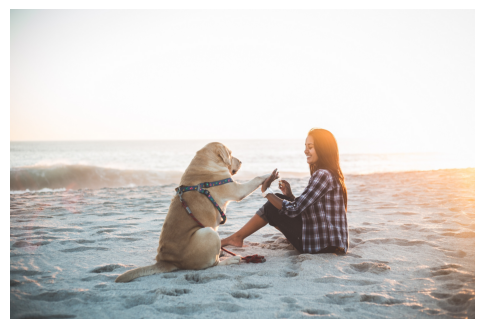

=== 실제 모델에 들어간 프롬프트 (이미지 토큰 요약) ===
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>이 이미지를 설명해줘.<|im_end|>
<|im_start|>assistant



In [26]:
import matplotlib.pyplot as plt
import re

# 반복되는 <|image_pad|> 토큰이 너무 길어서 요약해서 보기 좋게
readable_prompt = re.sub(r'(<\|image_pad\|>){2,}',
                          lambda m: f'<|image_pad|>×{len(m.group(0)) // len("<|image_pad|>")}',
                          text_prompt)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(image1)
ax.axis("off")
plt.show()

print("=== 실제 모델에 들어간 프롬프트 (이미지 토큰 요약) ===")
print(readable_prompt)


* attention map 시각화
<br> 중앙 패치만 attention

In [27]:
# 1. 특정 block의 qkv 출력 가로채기
captured_qkv = {}
block_idx = 13  # 27개 중 중간 정도 층 (원하는 층으로 바꿔도 됨)

def save_qkv(module, inp, out):
    captured_qkv["qkv"] = out.detach()

hook = vision_module.blocks[block_idx].attn.qkv.register_forward_hook(save_qkv)

with torch.no_grad():
    _ = vision_module(
        inputs["pixel_values"].to(vision_module.patch_embed.proj.weight.dtype),
        grid_thw=inputs["image_grid_thw"],
    )
hook.remove()

qkv = captured_qkv["qkv"]          # (num_patches, 3456)
print("qkv shape:", qkv.shape)

qkv shape: torch.Size([11008, 3456])


In [28]:
# Q, K, V로 분리 + head 나누기
num_heads = vis_cfg.num_heads          # 16
hidden_size = vis_cfg.hidden_size      # 1152
head_dim = hidden_size // num_heads    # 72

num_patches = qkv.shape[0]
qkv = qkv.reshape(num_patches, 3, num_heads, head_dim)  # (N, 3, heads, head_dim)
q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]                # 각각 (N, heads, head_dim)

# (heads, N, head_dim)로 변경
q = q.permute(1, 0, 2).float()
k = k.permute(1, 0, 2).float()

# softmax(QK^T / sqrt(d_k))
# ⚠️ rotary position embedding 적용 전 raw attention이라, 실제 모델 값과 100% 동일하진 않음 (경향성 참고용)
scale = head_dim ** 0.5

# 계산량 때문에 특정 query patch 몇 개만 선택해서 전체 이미지에 대한 attention만 봄
query_indices = [num_patches // 2]   # 이미지 중앙 patch 하나 선택 (원하는 인덱스로 변경 가능)

attn_maps = []
for qi in query_indices:
    q_sel = q[:, qi:qi+1, :]                     # (heads, 1, head_dim)
    scores = (q_sel @ k.transpose(-1, -2)) / scale  # (heads, 1, N)
    attn = torch.softmax(scores, dim=-1)[:, 0, :]    # (heads, N)
    attn_maps.append(attn)

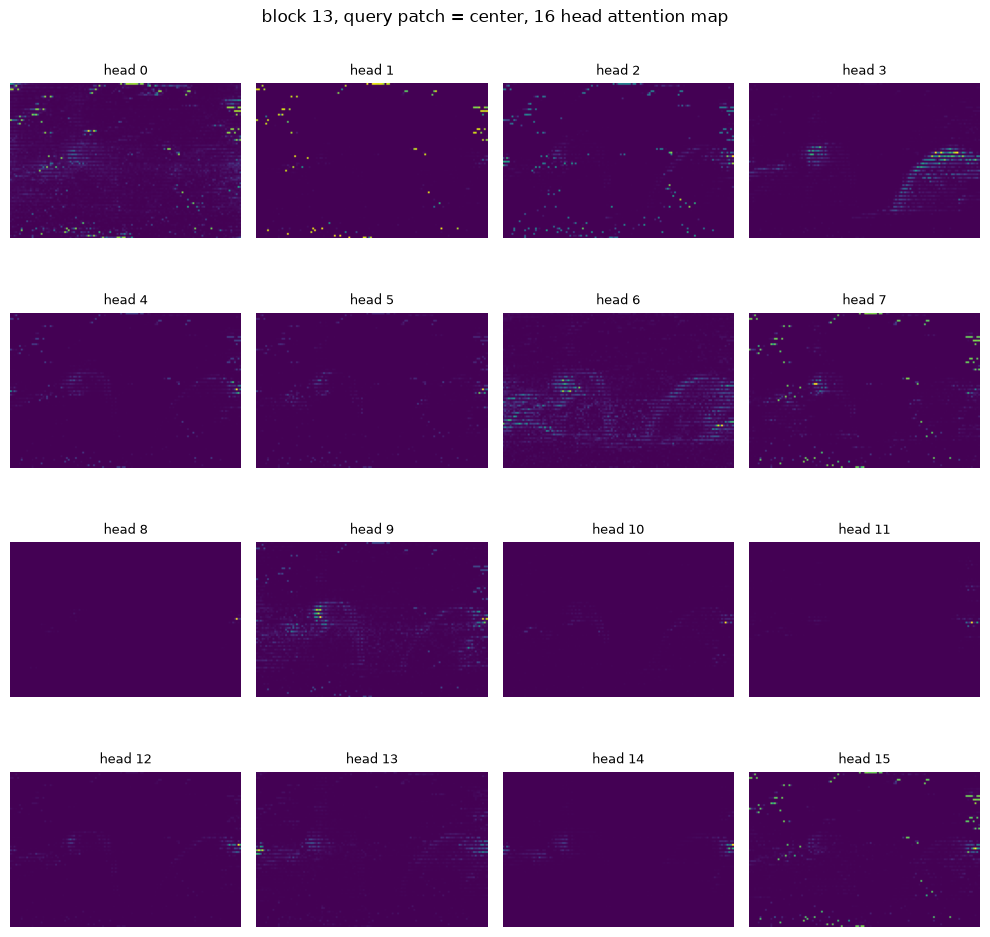

In [29]:
# head별로 (h, w) 공간에 reshape해서 heatmap — "이 patch가 이미지의 어디를 보고 있는가"
attn = attn_maps[0]  # (heads, N)
h, w = 86, 128        # 앞서 확인한 grid

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for head_idx, ax in enumerate(axes.flat):
    if head_idx >= num_heads:
        ax.axis("off")
        continue
    amap = attn[head_idx].reshape(h, w).cpu().numpy()
    im = ax.imshow(amap, cmap="viridis")
    ax.set_title(f"head {head_idx}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"block {block_idx}, query patch = center, 16 head attention map")
plt.tight_layout()
plt.show()

#### 7.5 Decoder → LM Head → 출력

In [33]:
with torch.no_grad():
    out = model(**inputs)  # generate가 아니라 forward 한 번만
    logits = out.logits
print(logits.shape)  # (1, 2769, 151936) ← 이게 lm_head의 진짜 raw 출력
print(logits[0, -1, :10])  # 마지막 토큰의 logits 출력

torch.Size([1, 2769, 151936])
tensor([ 0.3711,  7.1562,  6.5312,  3.1094,  0.2070,  0.9453,  5.1875,  6.3438,
        -0.5273,  7.3125], device='cuda:0', dtype=torch.bfloat16)


In [35]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False,
    )

generated_ids = outputs[0][inputs["input_ids"].shape[1]:]  # 입력 이후로 새로 생성된 부분만
generated_text = processor.tokenizer.decode(
    generated_ids, 
    skip_special_tokens=True
)

print(f"{'최종 lm_head 통과 후 생성된 토큰 수':25s}: {len(generated_ids)}")
print(f"생성된 텍스트:")
print(generated_text)

최종 lm_head 통과 후 생성된 토큰 수 : 300
생성된 텍스트:
이 이미지는 따뜻한 햇살이 비치는 해변에서 여자와 강아지가 함께 있는 평화로운 순간을 담고 있습니다.

**주요 요소:**

*   **여자:** 오른쪽에 앉아 있으며, 검은색과 흰색의 체크무늬 셔츠와 검은색 바지를 입고 있습니다. 그녀는 웃으며 강아지와 눈을 맞추고 있으며, 손에 간식을 들고 있는 듯 보입니다. 손목에는 백색의 시계나 팔찌를 착용하고 있습니다.
*   **강아지:** 왼쪽에 앉아 있으며, 노란색 라브라더(또는 유사한 품종)로 보입니다. 강아지는 흰색의 허리띠를 착용하고 있으며, 앞발을 들어 올려 여자의 손을 흔들며 ‘고개를 끄덕이거나 손을 흔들’하는 듯한 포즈를 취하고 있습니다. 이는 강아지가 훈련을 받거나 주인과의 상호작용을 즐기고 있음을 나타냅니다.
*   **배경:** 흐릿하게 처리된 바다와 하늘. 바닷


## Part C. 추론 / 파인튜닝

#### 8. Text Reasoning

#### 9. Batch Inference

#### 10. Fine-Tuning